# K-Medias aplicado a la base de datos Iris.

**Nombre:** Ana Camila López Ceballos. 

**Materia:** Grandes Bases de Datos.  


In [6]:
import pandas as pd
import matplotlib.pyplot as mp
import seaborn as sb
import os
from sklearn.cluster import KMeans

## Carga de la base de datos

In [7]:
dataset = pd.read_csv("iris.csv")
dataset

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica


## Seleccionar las variables

La base Iris tiene cuatro columnas numéricas y una columna de texto llamada `variety`.
Como K-Medias necesita datos numéricos, tomo las primeras cuatro columnas:

In [8]:
fields = dataset.iloc[:,[0,1,2,3]].values
fields

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [9]:
import warnings
warnings.filterwarnings("ignore")

## Criterio del codo
Aquí pruebo diferentes cantidades de clústeres, desde 1 hasta 10. Para cada cantidad se calcula el `WCSS`.
La idea es ver en qué punto la disminución empieza a hacerse más pequeña.

In [10]:
wcss = []
for index in range(1,11):
    kmeans = KMeans(n_clusters = index, init = "k-means++", random_state = 2)
    kmeans.fit(fields)

    wcss.append(kmeans.inertia_)

Ahora grafico esos resultados para poder ver el codo de manera más clara.


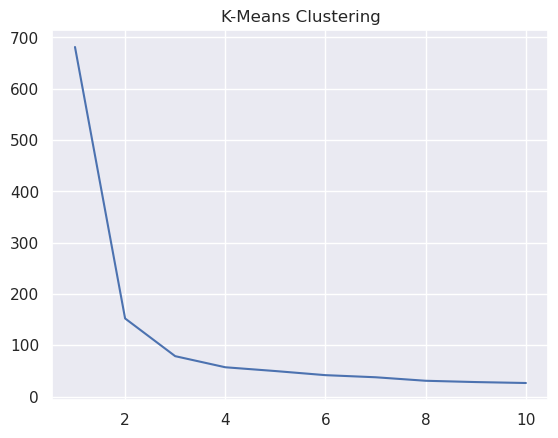

In [11]:
#Graficación del "Codo de Jambu"
sb.set()
mp.plot(range(1,11),wcss)
mp.title("K-Means Clustering")
mp.xlabel= ("Número de clusteres")
mp.ylabel = ("WCSS")


##  Aplicar K-Medias
Para Iris uso **3 clústeres** en esta parte. 

In [12]:
kmeans = KMeans(n_clusters = 3, init = "k-means++", random_state = 42)
cluster_values = kmeans.fit_predict(fields)
print(cluster_values)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 2 0 0 0 0 0 2 0 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]


##  Graficar los grupos
Como los grupos se calcularon usando las cuatro variables numéricas, para dibujarlos en una gráfica de dos dimensiones se muestran las primeras dos columnas: `sepal.length` y `sepal.width`.


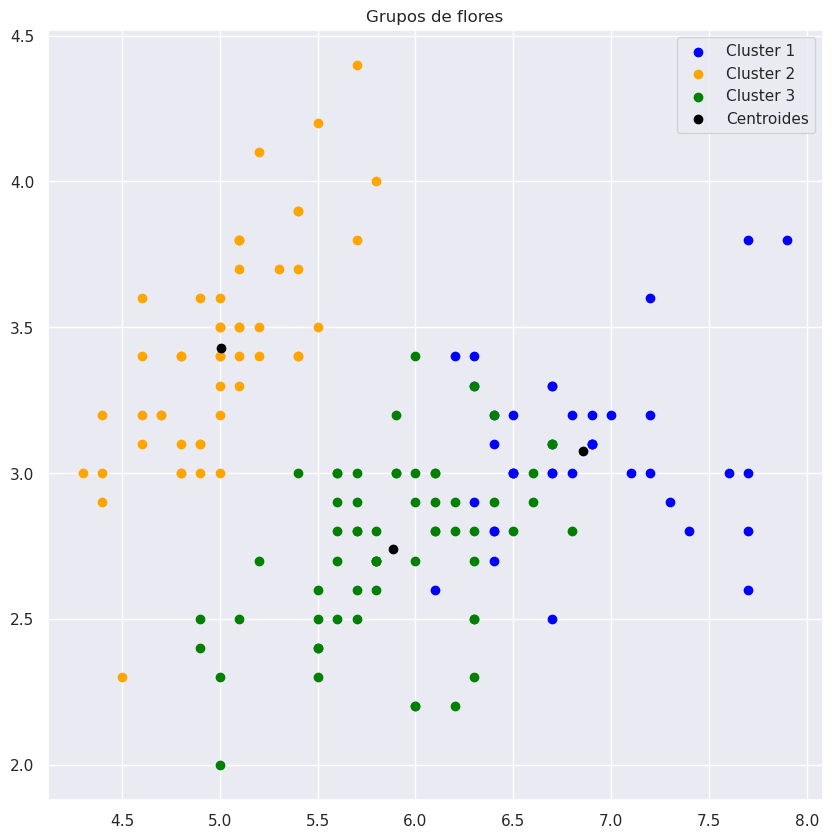

In [13]:
mp.figure(figsize=(10,10))
mp.scatter(fields[cluster_values == 0,0],fields[cluster_values==0,1], c= 'blue', label='Cluster 1')
mp.scatter(fields[cluster_values == 1,0],fields[cluster_values==1,1], c= 'orange', label='Cluster 2')
mp.scatter(fields[cluster_values == 2,0],fields[cluster_values==2,1], c= 'green', label='Cluster 3')

mp.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1], c='black', label='Centroides')

mp.title("Grupos de flores")
mp.xlabel = 'Sepal length'
mp.ylabel = 'Sepal width'
mp.legend()

##  Criterio de Silhouette.
Este criterio sirve para revisar qué tan bien separados quedan los grupos. Entre más alto sea el resultado, mejor separación hay entre los clústeres.

In [23]:
#Criterio de silueta ("Silhouette")
from sklearn import datasets
from sklearn.metrics import silhouette_score


En este bloque vuelvo a probar varias cantidades de clústeres. 


In [16]:
X= dataset.iloc[:,[0,1,2,3]].to_numpy()
for j in range (2,12):
    kmeans = KMeans(n_clusters = j, random_state =42)
    kmeans.fit_predict(X)

    score = silhouette_score (X, kmeans.labels_, metric="euclidean")
    print("Score Silhouete;","k=",j, ":" ,score)

Score Silhouete; k= 2 : 0.6810461692117465
Score Silhouete; k= 3 : 0.5511916046195927
Score Silhouete; k= 4 : 0.49764331793219296
Score Silhouete; k= 5 : 0.4930804067193529
Score Silhouete; k= 6 : 0.36784649847122536
Score Silhouete; k= 7 : 0.3542978877198859
Score Silhouete; k= 8 : 0.34467972180562056
Score Silhouete; k= 9 : 0.31558878533897866
Score Silhouete; k= 10 : 0.3014143745325154
Score Silhouete; k= 11 : 0.2687356216412038


# PCA
Ahora repito el procedimiento después de transformar los datos con **PCA**.

La diferencia es que antes tenía cuatro variables numéricas y ahora las voy a reducir a solo **dos componentes**. Esto permite trabajar la información en dos dimensiones.


In [17]:
fields2 = dataset.iloc[:,[0,1,2,3]].values
fields2

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [18]:
from sklearn import decomposition

pca = decomposition.PCA(n_components=2)
pca.fit(fields2)
fields2 = pca.transform(fields2)
fields2

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943],
       [-2.74534286, -0.31829898],
       [-2.72871654,  0.32675451],
       [-2.28085963,  0.74133045],
       [-2.82053775, -0.08946138],
       [-2.62614497,  0.16338496],
       [-2.88638273, -0.57831175],
       [-2.6727558 , -0.11377425],
       [-2.50694709,  0.6450689 ],
       [-2.61275523,  0.01472994],
       [-2.78610927, -0.235112  ],
       [-3.22380374, -0.51139459],
       [-2.64475039,  1.17876464],
       [-2.38603903,  1.33806233],
       [-2.62352788,  0.81067951],
       [-2.64829671,  0.31184914],
       [-2.19982032,  0.87283904],
       [-2.5879864 ,  0.51356031],
       [-2.31025622,  0.39134594],
       [-2.54370523,  0.43299606],
       [-3.21593942,  0.13346807],
       [-2.30273318,  0.09870885],
       [-2.35575405, -0.03728186],
       [-2.50666891, -0.14601688],
       [-2.46882007,  0.13095149],
       [-2.56231991,  0.36771886],
       [-2.63953472,

## Criterio del codo después de PCA

Ya con los datos reducidos a dos componentes, vuelvo a calcular el WCSS para diferentes cantidades de clústeres, exactamente con la misma lógica que antes.


In [24]:
wcss2 = []

for index in range(1,11):
    kmeans = KMeans(n_clusters = index, init = "k-means++", random_state = 2)
    kmeans.fit(fields2)

    wcss2.append(kmeans.inertia_)

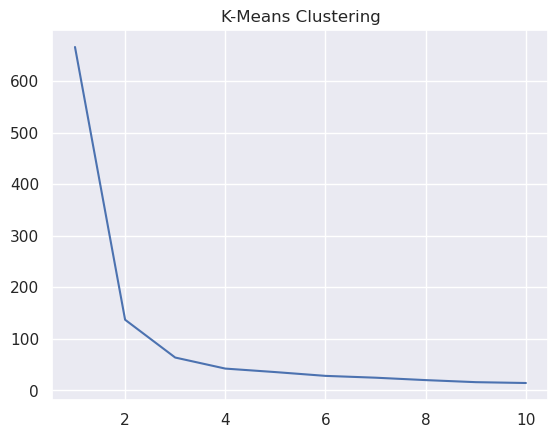

In [20]:
# Graficación del "Codo de Jambu"
sb.set()
mp.plot(range(1,11), wcss2)
mp.title("K-Means Clustering")
mp.xlabel= ("Número de clusteres")
mp.ylabel = ("WCSS")


##  K-Medias después de PCA

Después de reducir los datos, vuelvo a aplicar K-Medias con **3 clústeres** para poder ver cómo quedan los grupos ahora que solo tenemos dos componentes.


In [21]:
kmeans = KMeans(n_clusters = 3, init = "k-means++", random_state = 42)
cluster_values = kmeans.fit_predict(fields2)
print(cluster_values)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 2 0 0 0 0 0 2 0 0 0 0 2 0 0 0 2 0 0 0 2 0
 0 2]


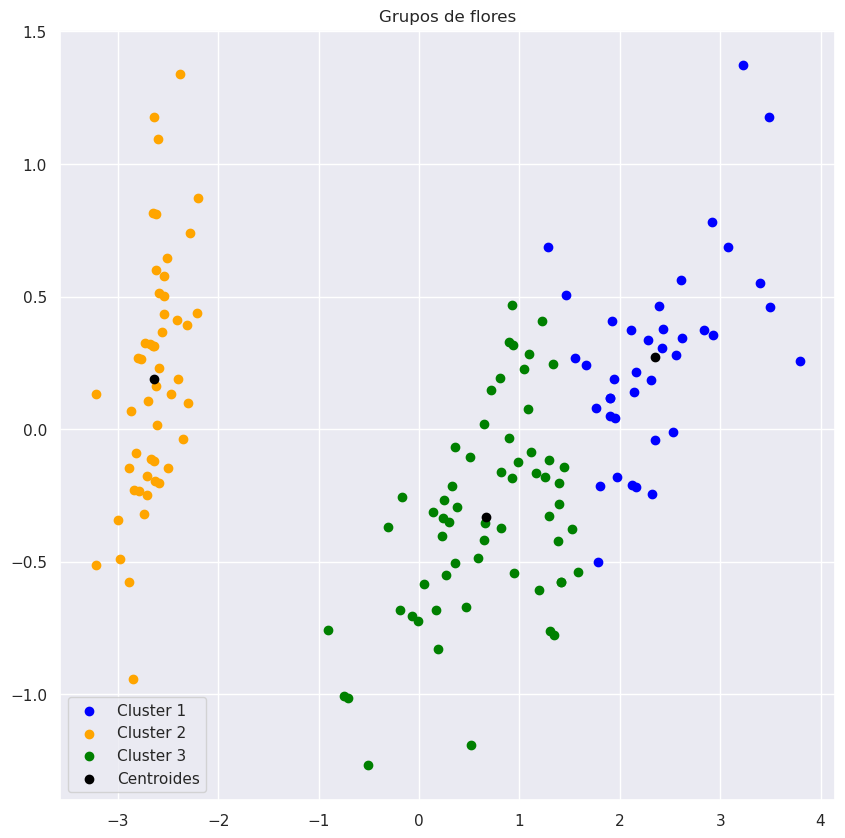

In [22]:
mp.figure(figsize=(10,10))

mp.scatter(fields2[cluster_values==0,0], fields2[cluster_values==0,1], c='blue', label='Cluster 1')
mp.scatter(fields2[cluster_values==1,0], fields2[cluster_values==1,1], c='orange', label='Cluster 2')
mp.scatter(fields2[cluster_values==2,0], fields2[cluster_values==2,1], c='green', label='Cluster 3')

mp.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c='black', label='Centroides')

mp.title("Grupos de flores")
mp.xlabel=("Componente 1")
mp.ylabel=("Componente 2")
mp.legend()

## Conclusiones.

Al comparar los resultados antes y después de aplicar PCA, podemos observar como los grupos que obtuvimos son muy parecidos, pero no necesariamente iguales. Esto pasa porque K-Medias trabaja con las cuatro variables numéricas originales, mientras que PCA solo trabaja con dos componentes que resumen toda la información.

En este caso PCA hace el análisis más sencillo, hace que sea más fácil visualizar los grupos en una gráfica y poder entender cómo se separan los datos.